# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

**Nama:**

**Email:**

**Id Dicoding:**

---
## 2. Persiapan

### 2.1 Menyiapkan Library yang Dibutuhkan

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

# Model Persistence
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('Semua library berhasil di-import!')

Semua library berhasil di-import!


### 2.2 Menyiapkan Data

In [2]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv', sep=';')

# Buat folder model jika belum ada
os.makedirs('model', exist_ok=True)

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
df.head()

Dataset berhasil dimuat!
Jumlah baris   : 4,424
Jumlah kolom   : 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


---
## 3. Data Understanding

Pada tahap ini kita akan memahami struktur data, distribusi nilai, dan karakteristik setiap fitur untuk mendapatkan insight awal sebelum melakukan preprocessing.

In [3]:
# Info umum dataset
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

In [4]:
# Statistik deskriptif
print('STATISTIK DESKRIPTIF')
df.describe().T.style.background_gradient(cmap='Blues')

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.000000,1.178571,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application_mode,4424.000000,18.669078,17.484682,1.000000,1.000000,17.000000,39.000000,57.000000
Application_order,4424.000000,1.727848,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.000000,8856.642631,2063.566416,33.000000,9085.000000,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.000000,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous_qualification,4424.000000,4.577758,10.216592,1.000000,1.000000,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.000000,132.613314,13.188332,95.000000,125.000000,133.100000,140.000000,190.000000
Nacionality,4424.000000,1.873192,6.914514,1.000000,1.000000,1.000000,1.000000,109.000000
Mothers_qualification,4424.000000,19.561935,15.603186,1.000000,2.000000,19.000000,37.000000,44.000000
Fathers_qualification,4424.000000,22.275316,15.343108,1.000000,3.000000,19.000000,37.000000,44.000000


In [5]:
# Cek missing values
missing = df.isnull().sum()
print('MISSING VALUES')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')

MISSING VALUES
Tidak ada missing values!


In [6]:
# Cek duplikat
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 0


### 3.1 Distribusi Target (Status Mahasiswa)

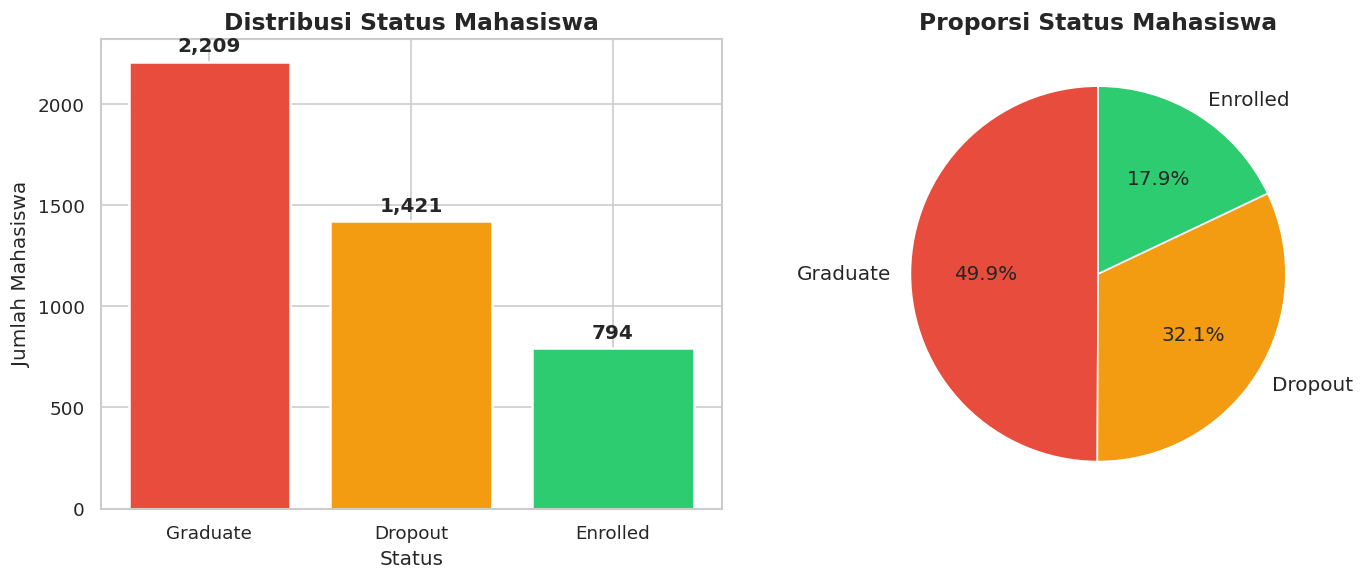


=== DISTRIBUSI TARGET ===
Graduate   : 2,209 (49.9%)
Dropout    : 1,421 (32.1%)
Enrolled   : 794 (17.9%)


In [7]:
# Distribusi kelas target
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#E74C3C', '#F39C12', '#2ECC71']
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('model/target_distribution.png', bbox_inches='tight')
plt.show()

print('\n=== DISTRIBUSI TARGET ===')
for status, count, pct in zip(status_counts.index, status_counts.values, status_pct.values):
    print(f'{status:10} : {count:,} ({pct:.1f}%)')

**Insight:** Dataset menunjukkan ketidakseimbangan kelas (*class imbalance*). Distribusi kelas: **Graduate 49.9%** (2.209 mahasiswa), **Dropout 32.1%** (1.421 mahasiswa), dan **Enrolled 17.9%** (794 mahasiswa). Kelas Enrolled yang paling sedikit dan Dropout yang mencapai hampir sepertiga dataset menjadi fokus utama analisis ini — model perlu menangani imbalance ini agar prediksi Dropout tidak bias.

### 3.2 Analisis Faktor Akademik

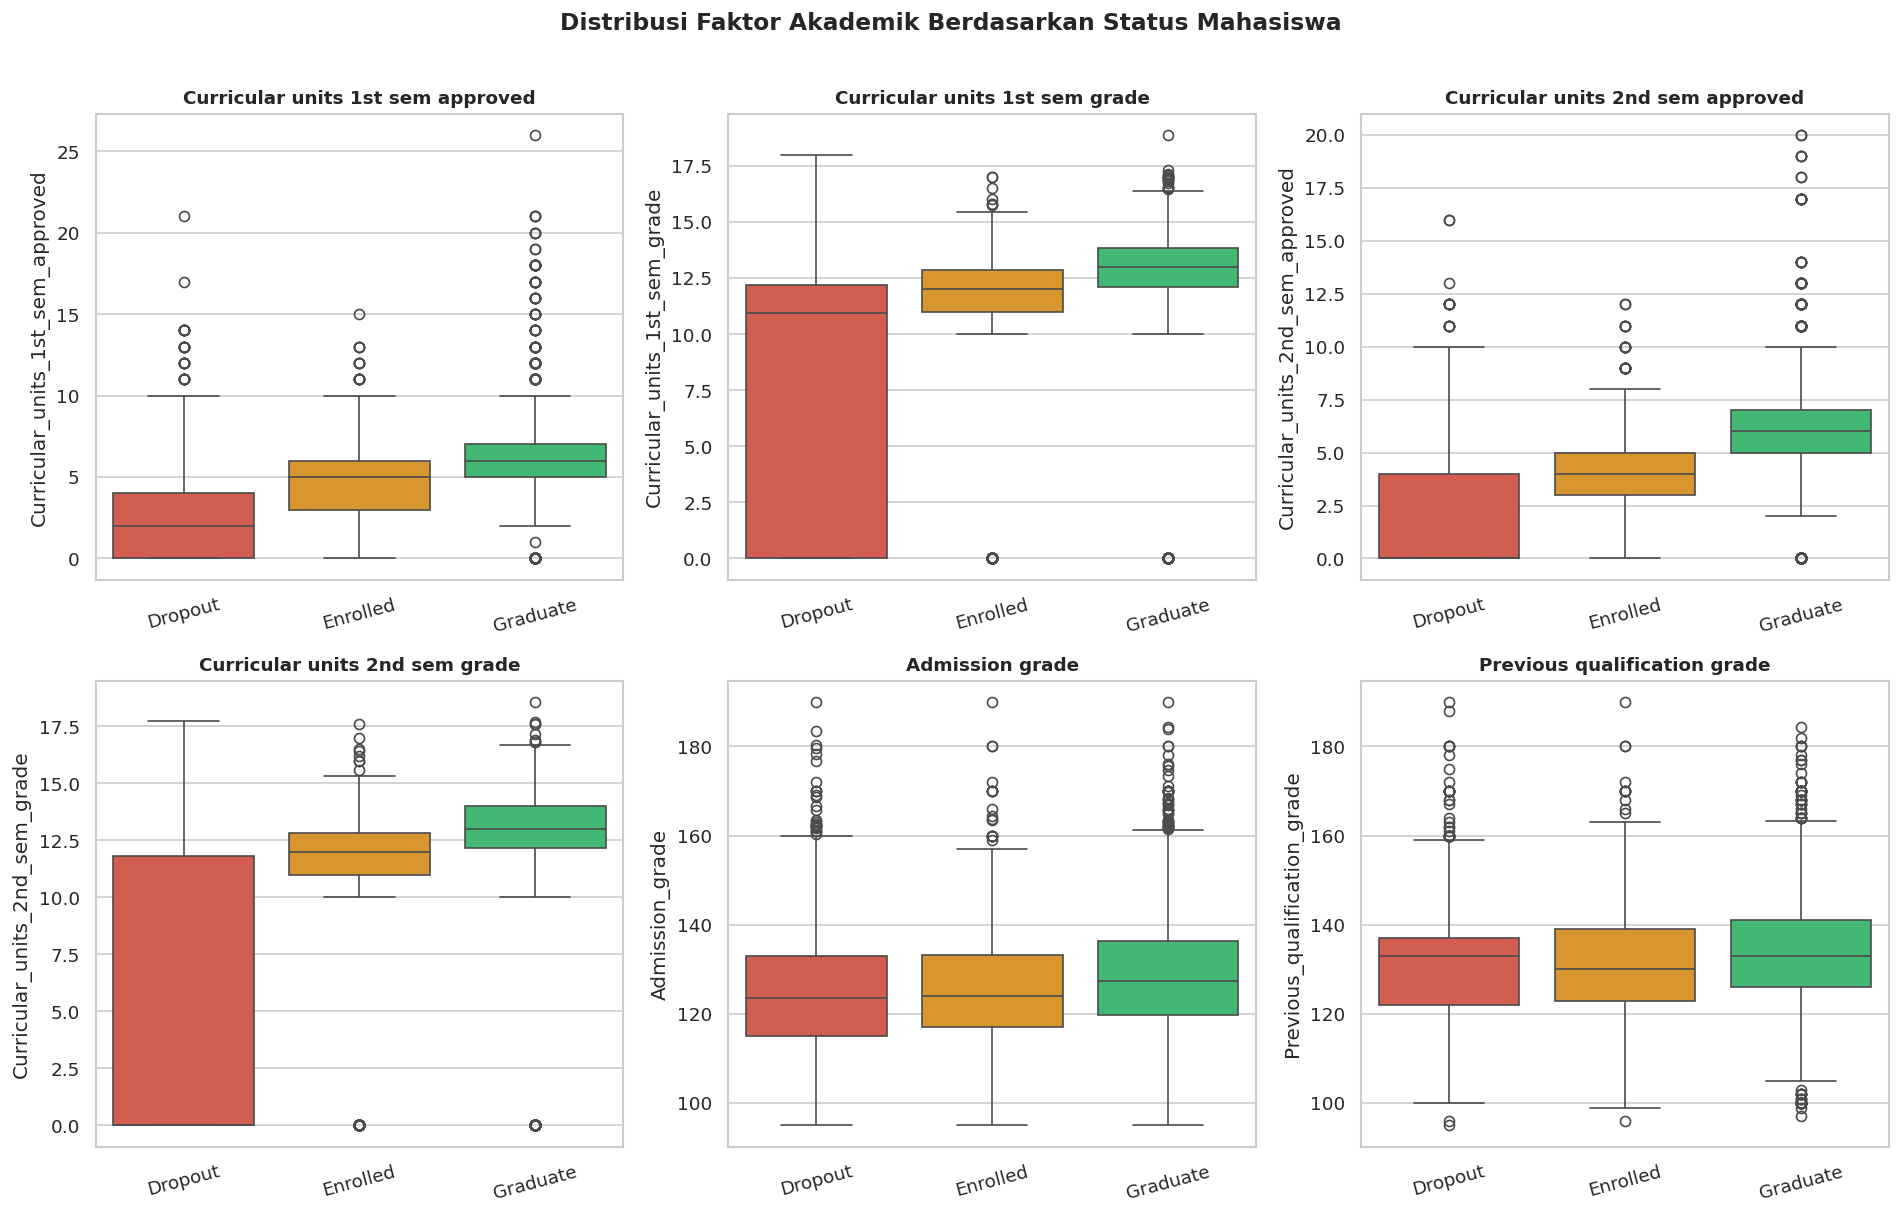

In [8]:
# Perbandingan nilai akademik berdasarkan status
academic_features = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Admission_grade',
    'Previous_qualification_grade'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

status_order = ['Dropout', 'Enrolled', 'Graduate']
palette = {'Dropout': '#E74C3C', 'Enrolled': '#F39C12', 'Graduate': '#2ECC71'}

for i, col in enumerate(academic_features):
    sns.boxplot(data=df, x='Status', y=col, order=status_order,
                palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribusi Faktor Akademik Berdasarkan Status Mahasiswa',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model/academic_factors.png', bbox_inches='tight')
plt.show()

**Insight:** Performa akademik adalah pembeda terkuat antar status mahasiswa:
- Mahasiswa **Dropout** memiliki rata-rata unit approved dan grade yang jauh lebih rendah di kedua semester
- Mahasiswa **Graduate** secara konsisten memiliki unit approved dan nilai tertinggi
- Mahasiswa **Enrolled** berada di tengah — masih aktif namun belum mencapai kelulusan

Temuan ini mengkonfirmasi bahwa performa akademik adalah sinyal prediktif paling kuat. Hal ini tercermin pada feature importance model terbaik (XGBoost), di mana `approval_rate_2nd` (rasio unit lulus semester 2) menjadi fitur paling informatif, diikuti oleh `Curricular_units_2nd_sem_approved` dan `approval_rate_1st`.

### 3.3 Analisis Faktor Demografis & Finansial

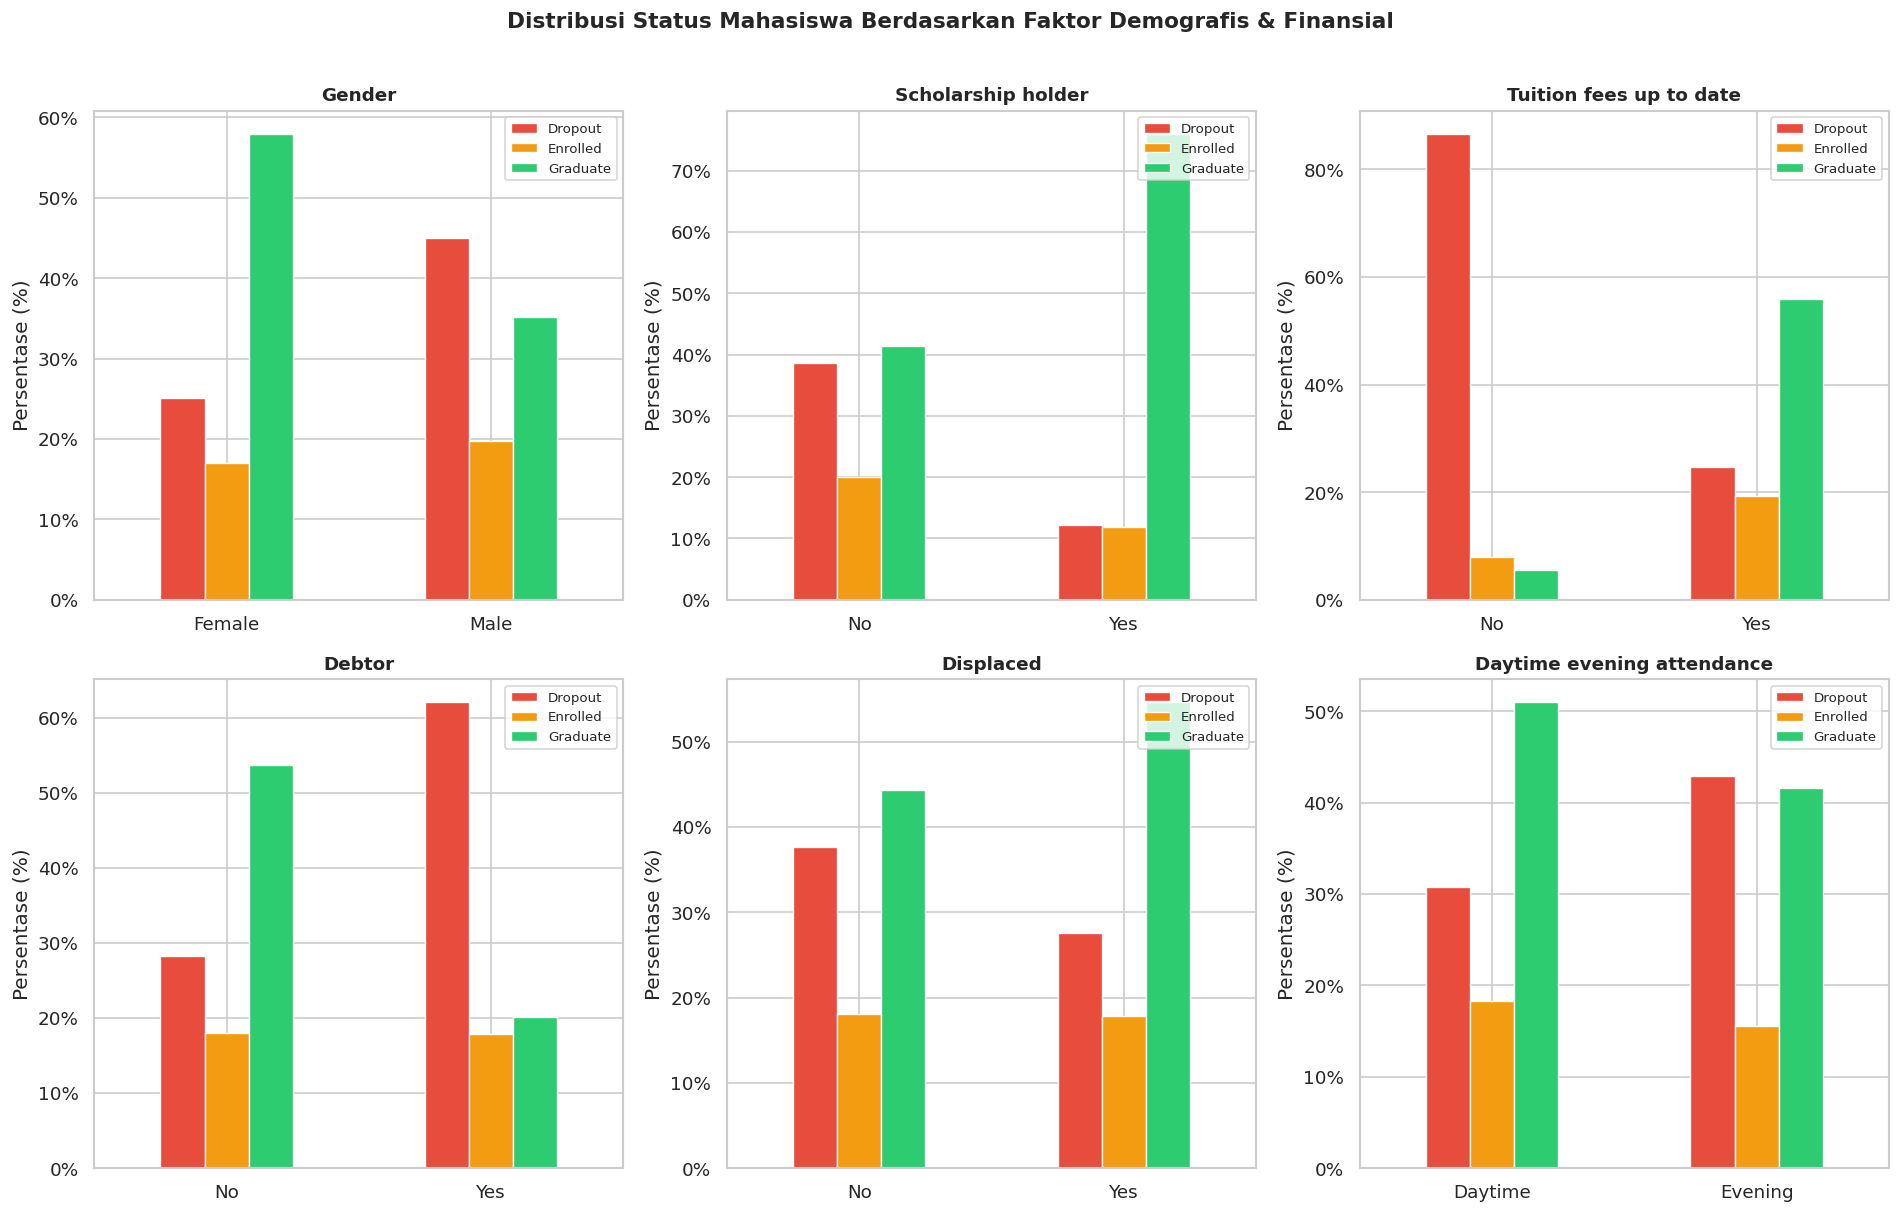

In [9]:
# Analisis fitur kategoris
cat_features = ['Gender', 'Scholarship_holder', 'Tuition_fees_up_to_date',
                'Debtor', 'Displaced', 'Daytime_evening_attendance']

cat_labels = {
    'Gender': {0: 'Female', 1: 'Male'},
    'Scholarship_holder': {0: 'No', 1: 'Yes'},
    'Tuition_fees_up_to_date': {0: 'No', 1: 'Yes'},
    'Debtor': {0: 'No', 1: 'Yes'},
    'Displaced': {0: 'No', 1: 'Yes'},
    'Daytime_evening_attendance': {0: 'Evening', 1: 'Daytime'}
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    temp_df = df.copy()
    temp_df[feat] = temp_df[feat].map(cat_labels[feat])

    cross = pd.crosstab(temp_df[feat], temp_df['Status'], normalize='index') * 100
    cross[['Dropout', 'Enrolled', 'Graduate']].plot(
        kind='bar', ax=axes[i], color=['#E74C3C', '#F39C12', '#2ECC71'],
        edgecolor='white', linewidth=0.8
    )
    axes[i].set_title(feat.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Distribusi Status Mahasiswa Berdasarkan Faktor Demografis & Finansial',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model/demographic_factors.png', bbox_inches='tight')
plt.show()

**Insight:**
- Mahasiswa yang **tidak up-to-date dalam pembayaran tuition** memiliki proporsi dropout yang sangat tinggi — dikonfirmasi oleh feature importance XGBoost: `Tuition_fees_up_to_date` berada di **rank ke-2** (importance: 0.092) setelah `approval_rate_2nd`
- Mahasiswa **penerima beasiswa (scholarship holder)** memiliki tingkat dropout yang lebih rendah — `Scholarship_holder` masuk top-10 feature importance (rank ke-10, importance: 0.023), membuktikan efek protektif beasiswa
- Mahasiswa yang **memiliki hutang (debtor)** menunjukkan kecenderungan dropout lebih tinggi
- Fitur `financial_risk` (gabungan tuition + debtor) yang ditambahkan melalui feature engineering berhasil masuk top-10 (rank ke-4, importance: 0.034), mengkonfirmasi relevansi kombinasi dua sinyal finansial ini

### 3.4 Analisis Usia saat Enrollment

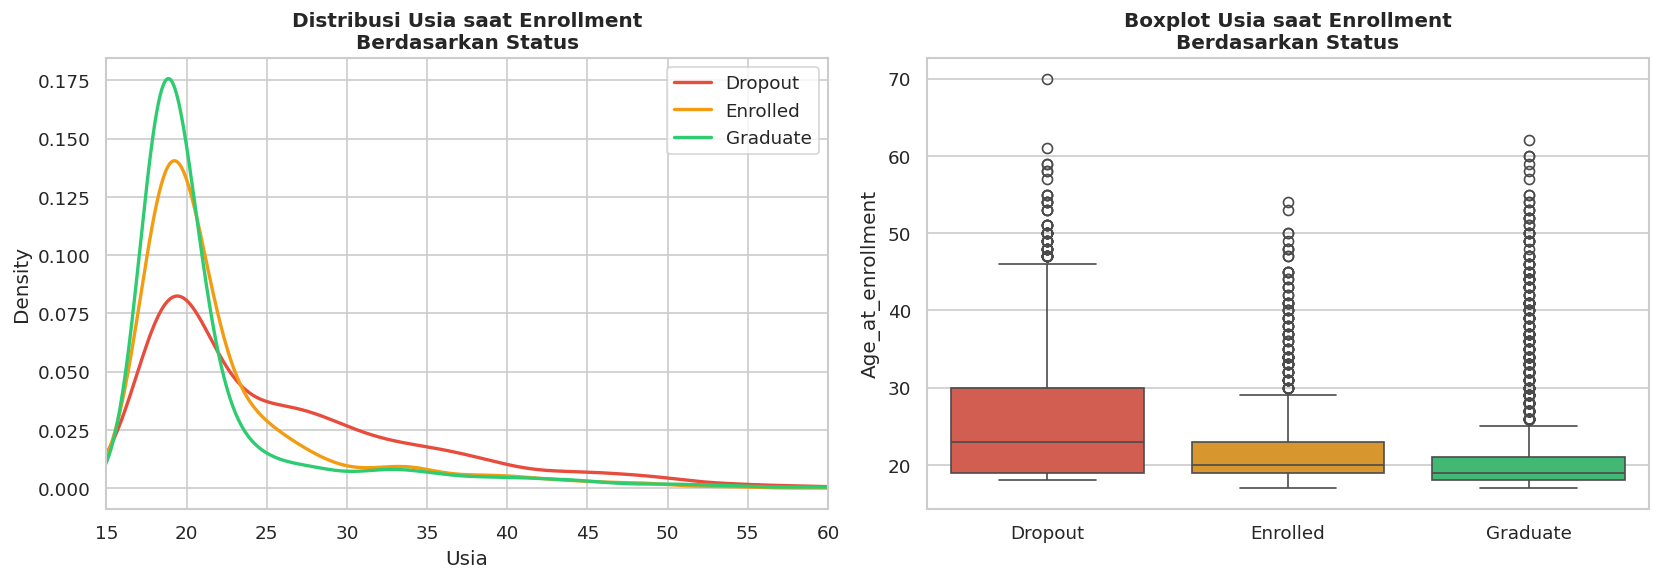

RATA-RATA USIA BERDASARKAN STATUS
           mean  median   std
Status                       
Dropout   26.07    23.0  8.70
Enrolled  22.37    20.0  6.30
Graduate  21.78    19.0  6.69


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot usia
for status in ['Dropout', 'Enrolled', 'Graduate']:
    subset = df[df['Status'] == status]['Age_at_enrollment']
    subset.plot.kde(ax=axes[0], label=status, linewidth=2,
                   color=palette[status])

axes[0].set_title('Distribusi Usia saat Enrollment\nBerdasarkan Status',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(15, 60)

# Boxplot usia
sns.boxplot(data=df, x='Status', y='Age_at_enrollment',
            order=status_order, palette=palette, ax=axes[1])
axes[1].set_title('Boxplot Usia saat Enrollment\nBerdasarkan Status',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('model/age_distribution.png', bbox_inches='tight')
plt.show()

print('RATA-RATA USIA BERDASARKAN STATUS')
print(df.groupby('Status')['Age_at_enrollment'].agg(['mean', 'median', 'std']).round(2))

**Insight:** Terdapat perbedaan usia yang signifikan antar kelompok status:
- **Dropout**: rata-rata usia 26.1 tahun (median 23), std 8.7
- **Enrolled**: rata-rata usia 22.4 tahun (median 20), std 6.3
- **Graduate**: rata-rata usia 21.8 tahun (median 19), std 6.7

Mahasiswa yang lebih tua saat enrollment cenderung memiliki risiko dropout lebih tinggi. Hal ini kemungkinan berkaitan dengan tanggung jawab lain di luar kampus (pekerjaan, keluarga). Setelah winsorizing, rentang usia dibatasi ke [18, 50] tahun untuk menghilangkan outlier ekstrem (max awal: 70).

### 3.5 Korelasi Antar Fitur

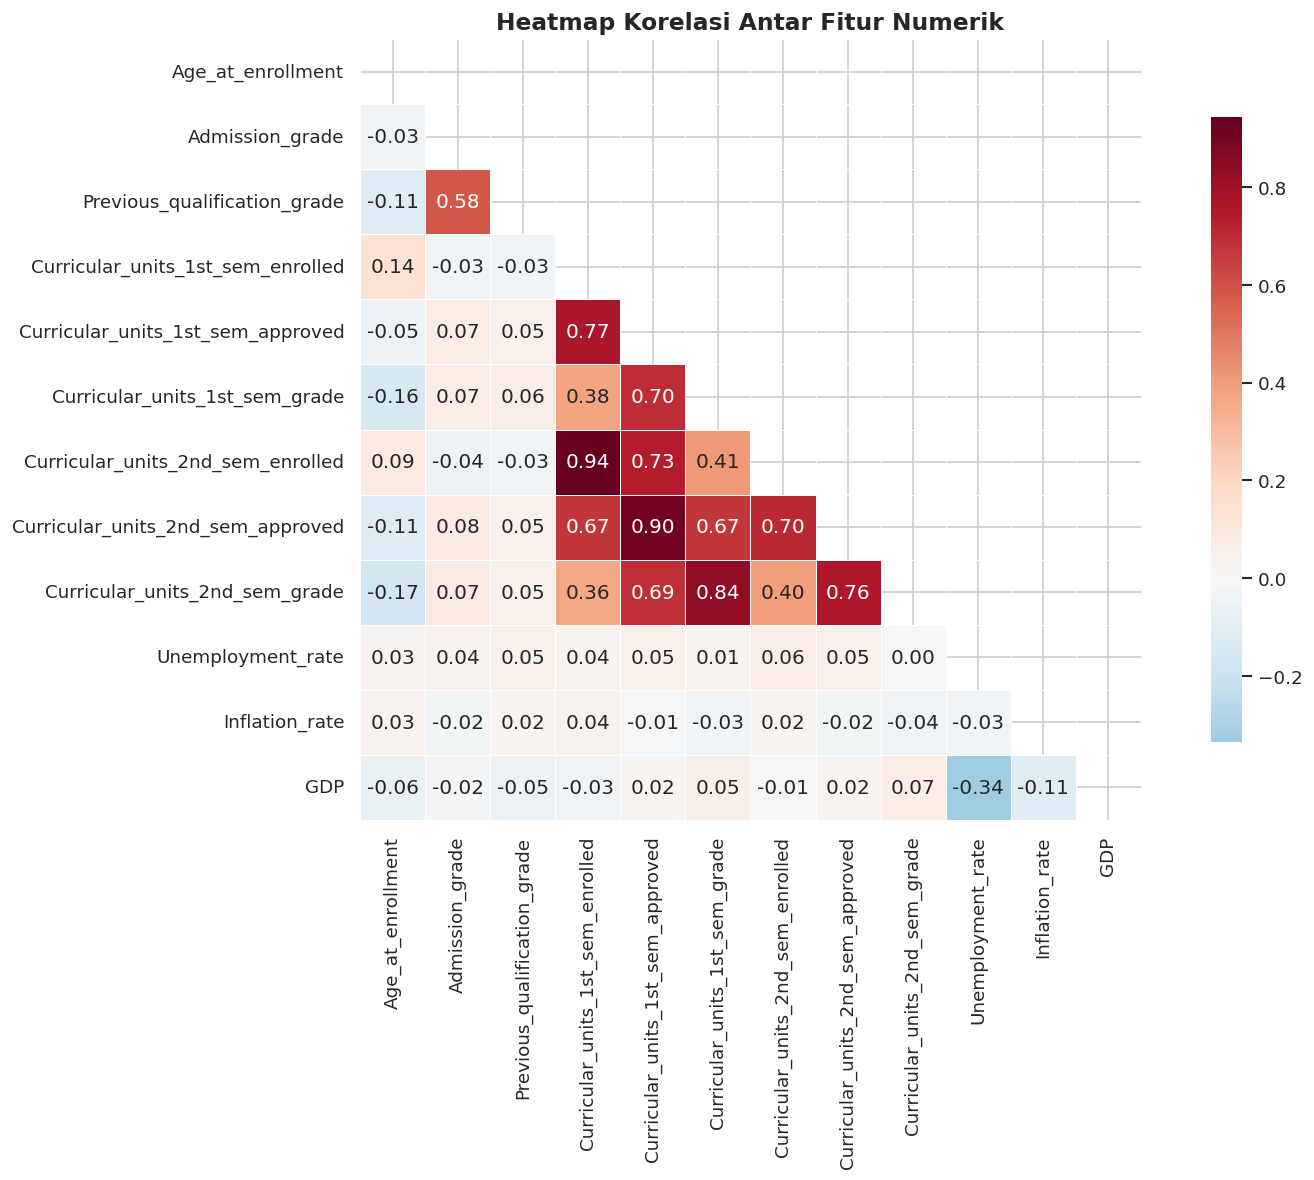

In [11]:
# Heatmap korelasi untuk fitur numerik utama
key_features = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model/correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 4. Data Preparation / Preprocessing

Pada tahap ini, kita akan mempersiapkan data untuk pemodelan:
1. **Outlier Handling** — Winsorizing (clip percentile 1%–99%) pada fitur numerik dengan distribusi ekstrem
2. **Encode target variable** — LabelEncoder untuk kolom `Status`
3. **Feature Engineering** — Membuat 6 fitur turunan berbasis domain knowledge untuk meningkatkan sinyal prediksi
4. **Identifikasi tipe fitur** — pisahkan fitur numerik kontinu (27+6) vs kategoris nominal (9)
5. **Train-Test Split** — 80:20 dengan stratify
6. **Pipeline preprocessing** — ColumnTransformer (StandardScaler + OrdinalEncoder) digabung Pipeline per model untuk mencegah data leakage
7. **Verifikasi distribusi kelas** — pastikan proporsi seimbang di train/test

In [12]:
# ── 1. Outlier Handling (Winsorizing) ─────────────────────────────────────
# Fitur numerik kontinu yang berpotensi outlier berdasarkan EDA
outlier_cols = [
    'Age_at_enrollment',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_2nd_sem_evaluations',
    'Admission_grade',
    'Previous_qualification_grade'
]

print('=== OUTLIER HANDLING (Winsorizing pada percentile 1%-99%) ===')
for col in outlier_cols:
    low, high = df[col].quantile([0.01, 0.99])
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = df[col].clip(lower=low, upper=high)
    print(f'  {col:<45} [{before_min:.1f}, {before_max:.1f}] → [{df[col].min():.1f}, {df[col].max():.1f}]')

print()

# ── 2. Encode target variable ─────────────────────────────────────────────
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])

print('Mapping Label Encoding:')
for i, label in enumerate(le.classes_):
    print(f'  {label} -> {i}')

# Simpan label encoder
os.makedirs('model', exist_ok=True)
joblib.dump(le, 'model/label_encoder.pkl')
print('\nLabel encoder tersimpan di model/label_encoder.pkl')

=== OUTLIER HANDLING (Winsorizing pada percentile 1%-99%) ===
  Age_at_enrollment                             [17.0, 70.0] → [18.0, 50.0]
  Curricular_units_1st_sem_evaluations          [0.0, 45.0] → [0.0, 21.0]
  Curricular_units_2nd_sem_evaluations          [0.0, 33.0] → [0.0, 19.0]
  Admission_grade                               [95.0, 190.0] → [99.0, 166.8]
  Previous_qualification_grade                  [95.0, 190.0] → [100.0, 170.0]

Mapping Label Encoding:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Label encoder tersimpan di model/label_encoder.pkl


In [13]:
# ── 3. Feature Engineering ───────────────────────────────────────────────
# Tambah fitur turunan berdasarkan domain knowledge untuk meningkatkan sinyal prediksi

# Approval rate: rasio unit lulus / unit enrolled (menangkap efisiensi akademik)
df['approval_rate_1st'] = df['Curricular_units_1st_sem_approved'] / (df['Curricular_units_1st_sem_enrolled'] + 1e-6)
df['approval_rate_2nd'] = df['Curricular_units_2nd_sem_approved'] / (df['Curricular_units_2nd_sem_enrolled'] + 1e-6)

# Total unit lulus dan rata-rata nilai kedua semester
df['total_approved'] = df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']
df['avg_grade']       = (df['Curricular_units_1st_sem_grade'] + df['Curricular_units_2nd_sem_grade']) / 2

# Financial risk score: gabungan tuition tidak up-to-date + debtor (0, 1, atau 2)
df['financial_risk'] = ((1 - df['Tuition_fees_up_to_date']) + df['Debtor']).clip(0, 2)

# Total unit yang di-enroll kedua semester
df['enrolled_total'] = df['Curricular_units_1st_sem_enrolled'] + df['Curricular_units_2nd_sem_enrolled']

print('✅ Feature engineering selesai. Fitur baru yang ditambahkan:')
new_feats = ['approval_rate_1st','approval_rate_2nd','total_approved','avg_grade','financial_risk','enrolled_total']
for f in new_feats:
    print(f'   + {f}')

# ── Definisikan fitur dan target ──────────────────────────────────────────
feature_cols = [col for col in df.columns if col not in ['Status', 'Status_encoded']]

X = df[feature_cols]
y = df['Status_encoded']

# Pisahkan tipe kolom:
#   - numeric_cols    : fitur numerik kontinu → StandardScaler
#   - categorical_cols: fitur nominal/ordinal dengan kode integer → OrdinalEncoder
categorical_cols = [
    'Marital_status', 'Application_mode', 'Course',
    'Previous_qualification', 'Nacionality',
    'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation'
]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print(f'\nJumlah fitur total     : {len(feature_cols)}')
print(f'Fitur numerik          : {len(numeric_cols)}')
print(f'Fitur kategoris/nominal: {len(categorical_cols)}')
print()
print('Fitur numerik (akan di-scale):')
for c in numeric_cols:
    print(f'  - {c}')
print('\nFitur kategoris (akan di-encode):')
for c in categorical_cols:
    print(f'  - {c}')

✅ Feature engineering selesai. Fitur baru yang ditambahkan:
   + approval_rate_1st
   + approval_rate_2nd
   + total_approved
   + avg_grade
   + financial_risk
   + enrolled_total

Jumlah fitur total     : 42
Fitur numerik          : 33
Fitur kategoris/nominal: 9

Fitur numerik (akan di-scale):
  - Application_order
  - Daytime_evening_attendance
  - Previous_qualification_grade
  - Admission_grade
  - Displaced
  - Educational_special_needs
  - Debtor
  - Tuition_fees_up_to_date
  - Gender
  - Scholarship_holder
  - Age_at_enrollment
  - International
  - Curricular_units_1st_sem_credited
  - Curricular_units_1st_sem_enrolled
  - Curricular_units_1st_sem_evaluations
  - Curricular_units_1st_sem_approved
  - Curricular_units_1st_sem_grade
  - Curricular_units_1st_sem_without_evaluations
  - Curricular_units_2nd_sem_credited
  - Curricular_units_2nd_sem_enrolled
  - Curricular_units_2nd_sem_evaluations
  - Curricular_units_2nd_sem_approved
  - Curricular_units_2nd_sem_grade
  - Curricu

In [14]:
# Simpan daftar nama fitur
joblib.dump(feature_cols, 'model/feature_names.pkl')

# ── 4. Train-Test Split dengan stratify ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'=== PEMBAGIAN DATA ===')
print(f'Training set  : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set   : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

=== PEMBAGIAN DATA ===
Training set  : 3,539 samples (80.0%)
Testing set   : 885 samples (20.0%)


In [15]:
# Verifikasi distribusi kelas pada train dan test
print('Distribusi kelas - Training:')
for cls, count in zip(le.classes_, np.bincount(y_train)):
    print(f'  {cls}: {count} ({count/len(y_train)*100:.1f}%)')

print('\nDistribusi kelas - Testing:')
for cls, count in zip(le.classes_, np.bincount(y_test)):
    print(f'  {cls}: {count} ({count/len(y_test)*100:.1f}%)')

Distribusi kelas - Training:
  Dropout: 1137 (32.1%)
  Enrolled: 635 (17.9%)
  Graduate: 1767 (49.9%)

Distribusi kelas - Testing:
  Dropout: 284 (32.1%)
  Enrolled: 159 (18.0%)
  Graduate: 442 (49.9%)


In [16]:
# ── 5. Buat ColumnTransformer sebagai preprocessor ────────────────────────
# StandardScaler  → fitur numerik kontinu
# OrdinalEncoder  → fitur kategoris (kode integer nominal)
# Catatan: tree-based models tidak butuh scaling, tapi memakai preprocessor
#          yang sama memastikan konsistensi dan tidak ada data leakage di CV.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='drop'  # hanya pakai kolom yang sudah didefinisikan
)

# Simpan preprocessor (akan di-fit di dalam Pipeline)
print('Preprocessor (ColumnTransformer) siap digunakan di dalam Pipeline.')
print('Scaling dan encoding dilakukan DI DALAM Pipeline sehingga aman dari data leakage.')

Preprocessor (ColumnTransformer) siap digunakan di dalam Pipeline.
Scaling dan encoding dilakukan DI DALAM Pipeline sehingga aman dari data leakage.


---
## 5. Modeling

Kita akan melatih beberapa model klasifikasi dan membandingkan performanya untuk memilih model terbaik.

Model yang digunakan:
1. **Logistic Regression** — baseline model, menggunakan `class_weight='balanced'`
2. **Decision Tree** — interpretable model, menggunakan `class_weight='balanced'`
3. **Random Forest** — ensemble bagging, menggunakan `class_weight='balanced'`
4. **Gradient Boosting** — ensemble boosting, menggunakan `sample_weight` untuk class imbalance
5. **XGBoost** — optimized gradient boosting, menggunakan `sample_weight` untuk class imbalance

Setiap model dibungkus dalam **Pipeline** (ColumnTransformer + classifier) untuk mencegah data leakage saat cross-validation. Evaluasi menggunakan **5-Fold Stratified CV** dengan metrik F1-Weighted, serta evaluasi akhir pada test set dengan Accuracy, F1-Macro, F1-Weighted, dan ROC-AUC.

In [17]:
# ── Definisikan semua model dalam Pipeline ────────────────────────────────
# Hyperparameter di-tune
# Setiap model dibungkus Pipeline(preprocessor + model) sehingga:
#   1. Tidak ada data leakage saat cross-validation
#   2. Scaling/encoding konsisten untuk semua model

from sklearn.utils.class_weight import compute_sample_weight

base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, C=0.5, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=2, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=1,
        min_samples_split=2, max_features='sqrt',
        random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, min_samples_leaf=5, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='mlogloss',
        use_label_encoder=False)
}

# Bungkus setiap model dengan Pipeline
models = {
    name: Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    for name, model in base_models.items()
}

# Sample weights untuk GBM & XGBoost (tidak support class_weight parameter)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Cross-validation
print('=== CROSS-VALIDATION (5-Fold Stratified) ===')
print(f'{"Model":<25} {"CV Mean":>10} {"CV Std":>10}')
print('-' * 48)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}     {scores.std():.4f}')

=== CROSS-VALIDATION (5-Fold Stratified) ===
Model                        CV Mean     CV Std
------------------------------------------------
Logistic Regression       0.7554     0.0132
Decision Tree             0.7111     0.0174
Random Forest             0.7671     0.0122
Gradient Boosting         0.7686     0.0155
XGBoost                   0.7672     0.0123


In [18]:
# ── Latih semua model dan evaluasi pada test set ──────────────────────────
print('=== EVALUASI PADA TEST SET ===')
print(f'{"Model":<25} {"Accuracy":>10} {"F1-Macro":>10} {"F1-Weighted":>12} {"ROC-AUC":>10}')
print('-' * 72)

results = {}
for name, pipeline in models.items():
    # GBM & XGBoost tidak support class_weight → pakai sample_weight
    if name in ('Gradient Boosting', 'XGBoost'):
        pipeline.fit(X_train, y_train,
                     classifier__sample_weight=sample_weights)
    else:
        pipeline.fit(X_train, y_train)

    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    f1w = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    results[name] = {
        'accuracy': acc, 'f1_macro': f1m, 'f1_weighted': f1w,
        'roc_auc': auc, 'y_pred': y_pred, 'model': pipeline
    }
    print(f'{name:<25} {acc:.4f}     {f1m:.4f}       {f1w:.4f}    {auc:.4f}')

=== EVALUASI PADA TEST SET ===
Model                       Accuracy   F1-Macro  F1-Weighted    ROC-AUC
------------------------------------------------------------------------
Logistic Regression       0.7345     0.6965       0.7482    0.8972
Decision Tree             0.6791     0.6333       0.6928    0.7870
Random Forest             0.7763     0.7005       0.7638    0.9079
Gradient Boosting         0.7582     0.7066       0.7593    0.8988
XGBoost                   0.7684     0.7197       0.7698    0.9032


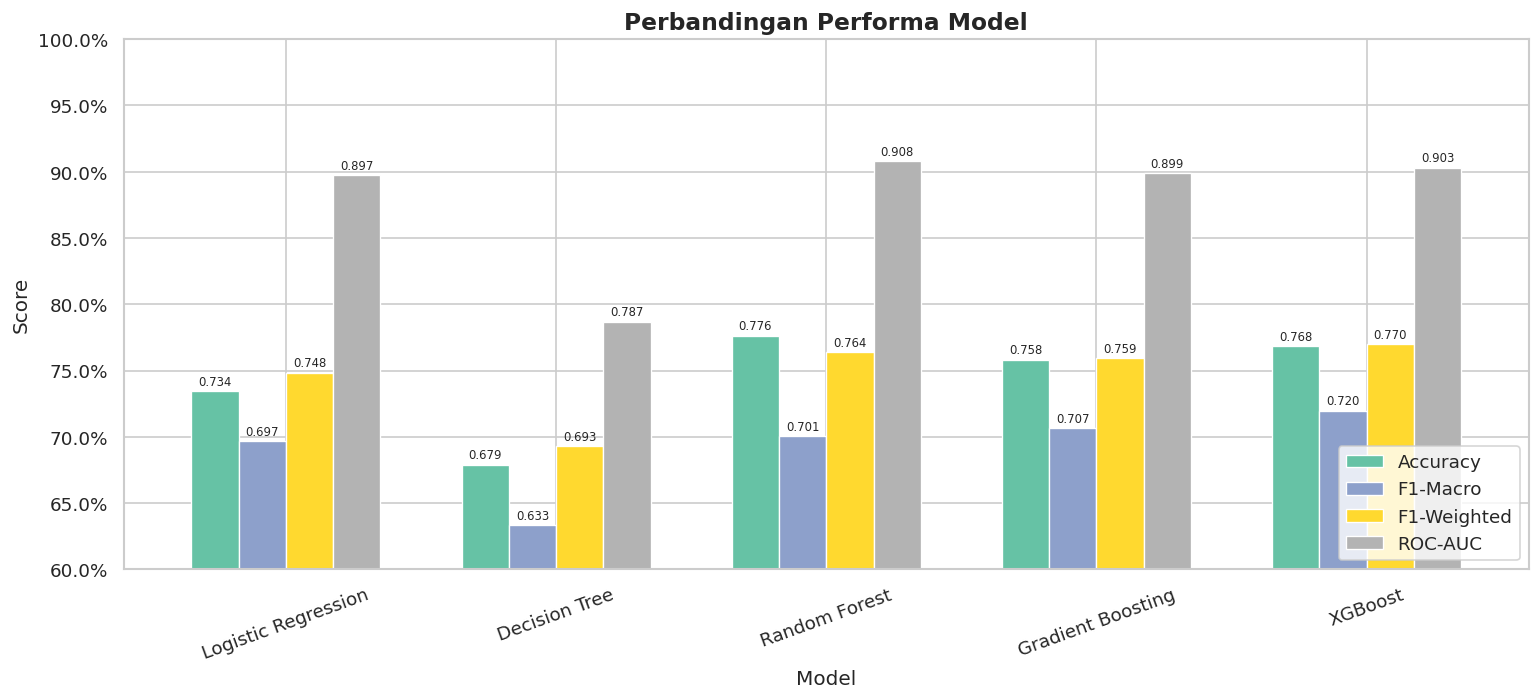


🏆 Model Terbaik: XGBoost
   Accuracy    : 0.7684
   F1-Macro    : 0.7197
   F1-Weighted : 0.7698
   ROC-AUC     : 0.9032


In [19]:
# Visualisasi perbandingan model
result_df = pd.DataFrame({
    'Model'       : list(results.keys()),
    'Accuracy'    : [results[m]['accuracy']    for m in results],
    'F1-Macro'    : [results[m]['f1_macro']    for m in results],
    'F1-Weighted' : [results[m]['f1_weighted'] for m in results],
    'ROC-AUC'     : [results[m]['roc_auc']     for m in results],
}).set_index('Model')

fig, ax = plt.subplots(figsize=(13, 6))
result_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.8, width=0.7)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.6, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=20)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('model/model_comparison.png', bbox_inches='tight')
plt.show()

# Pilih model terbaik berdasarkan F1-Weighted
best_model_name = result_df['F1-Weighted'].idxmax()
print(f'\n🏆 Model Terbaik: {best_model_name}')
print(f'   Accuracy    : {result_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'   F1-Macro    : {result_df.loc[best_model_name, "F1-Macro"]:.4f}')
print(f'   F1-Weighted : {result_df.loc[best_model_name, "F1-Weighted"]:.4f}')
print(f'   ROC-AUC     : {result_df.loc[best_model_name, "ROC-AUC"]:.4f}')

---
## 6. Evaluation

Evaluasi mendalam terhadap **model terbaik (XGBoost)** menggunakan confusion matrix, classification report, dan feature importance.

XGBoost dipilih karena memiliki **F1-Weighted tertinggi (0.7698)** dan **ROC-AUC 0.9032** di antara semua model yang diuji, menunjukkan kemampuan diskriminasi antar kelas yang sangat baik.

In [20]:
# Evaluasi model terbaik
best_pipeline  = results[best_model_name]['model']   # Pipeline objek
best_model     = best_pipeline.named_steps['classifier']  # model di dalam Pipeline
y_pred_best    = results[best_model_name]['y_pred']

print(f'=== CLASSIFICATION REPORT: {best_model_name} ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== CLASSIFICATION REPORT: XGBoost ===
              precision    recall  f1-score   support

     Dropout       0.82      0.72      0.77       284
    Enrolled       0.51      0.57      0.54       159
    Graduate       0.84      0.87      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.72      0.72       885
weighted avg       0.77      0.77      0.77       885



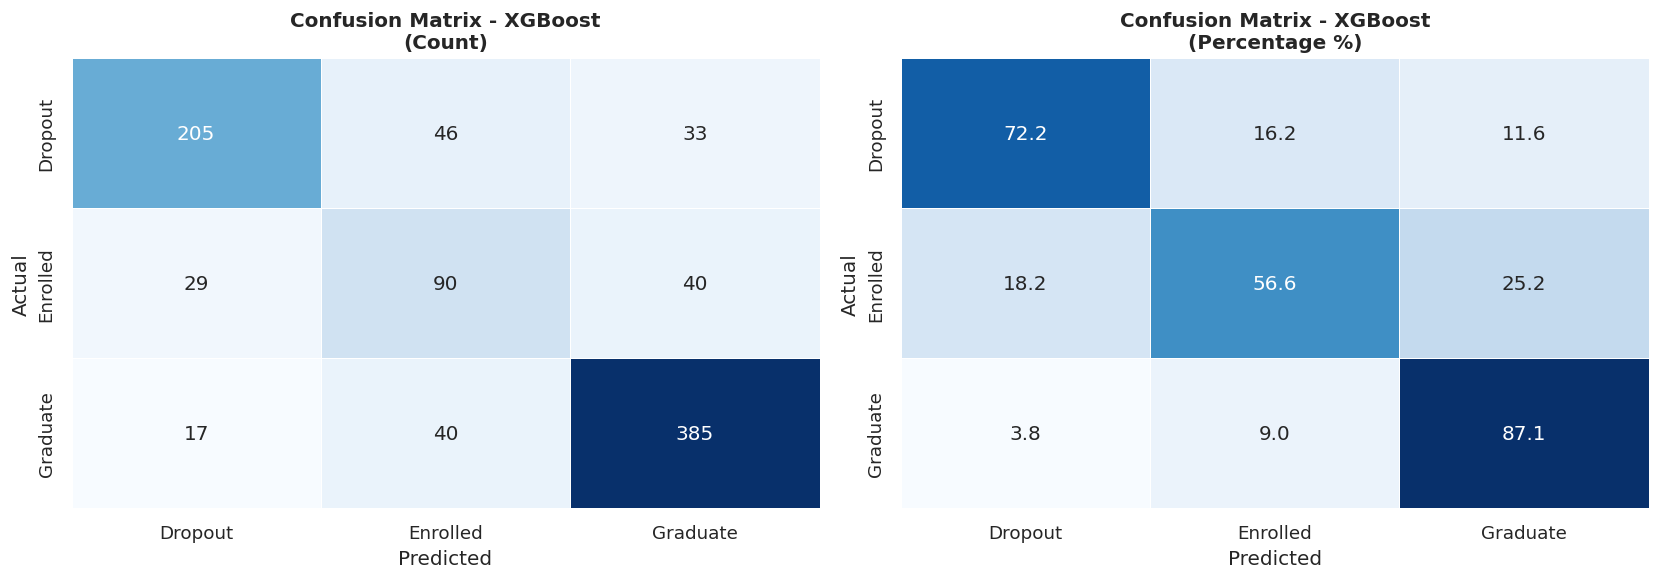

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix - counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, cbar=False)
axes[0].set_title(f'Confusion Matrix - {best_model_name}\n(Count)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion matrix - percentage
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, cbar=False)
axes[1].set_title(f'Confusion Matrix - {best_model_name}\n(Percentage %)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model/confusion_matrix.png', bbox_inches='tight')
plt.show()

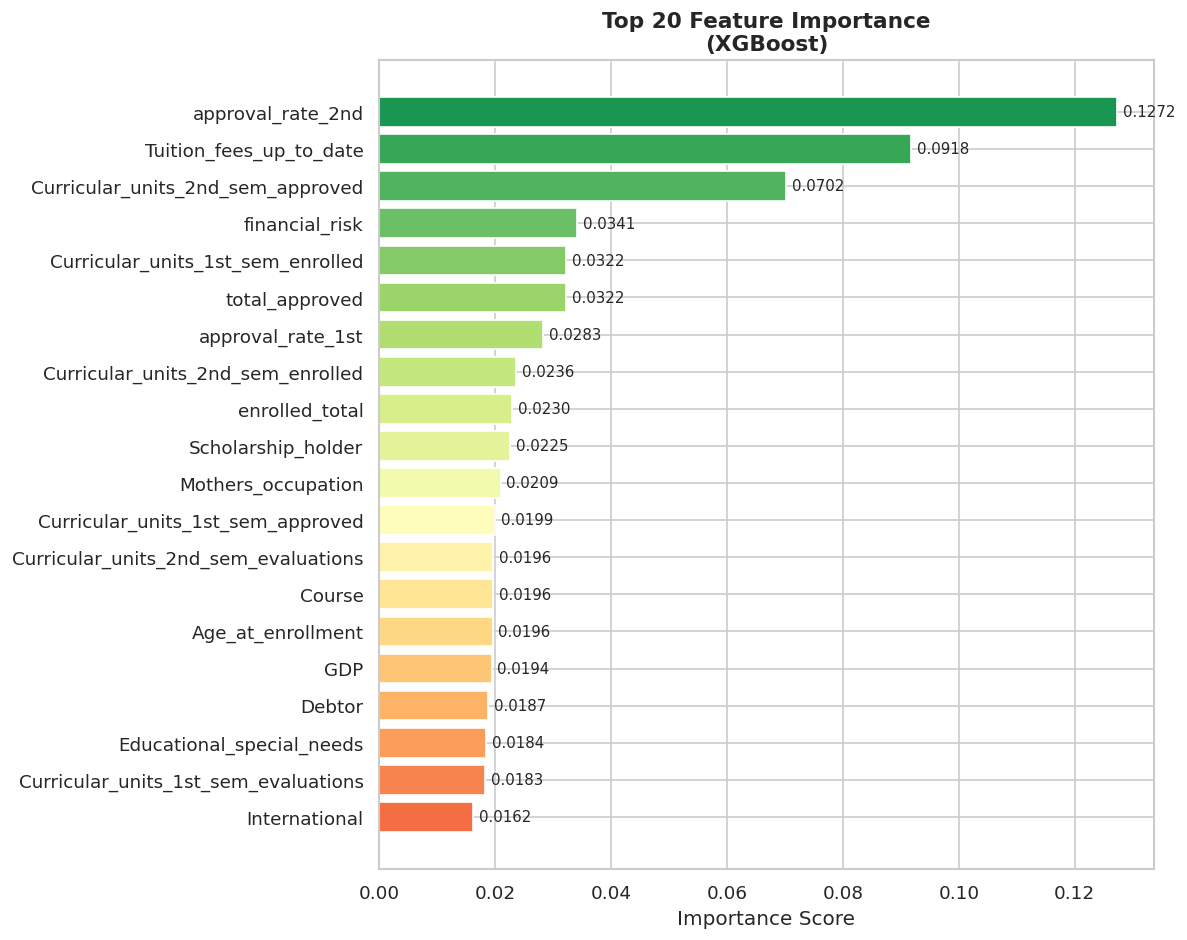


=== TOP 10 FITUR PALING PENTING ===
approval_rate_2nd                    0.127247
Tuition_fees_up_to_date              0.091779
Curricular_units_2nd_sem_approved    0.070179
financial_risk                       0.034067
Curricular_units_1st_sem_enrolled    0.032235
total_approved                       0.032182
approval_rate_1st                    0.028321
Curricular_units_2nd_sem_enrolled    0.023641
enrolled_total                       0.022951
Scholarship_holder                   0.022527


In [22]:
# Feature Importance — ambil nama fitur dari ColumnTransformer
if hasattr(best_model, 'feature_importances_'):
    preprocessor_fitted = best_pipeline.named_steps['preprocessor']
    # Gabungkan nama fitur: numeric dulu, lalu categorical (sesuai urutan ColumnTransformer)
    transformed_feature_names = numeric_cols + categorical_cols

    importances = pd.Series(best_model.feature_importances_, index=transformed_feature_names)
    top20 = importances.nlargest(20).sort_values()

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top20)))
    bars = ax.barh(top20.index, top20.values, color=colors_bar, edgecolor='white')
    ax.set_title(f'Top 20 Feature Importance\n({best_model_name})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

    for bar, val in zip(bars, top20.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{val:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('model/feature_importance.png', bbox_inches='tight')
    plt.show()

    print('\n=== TOP 10 FITUR PALING PENTING ===')
    print(importances.nlargest(10).to_string())
elif hasattr(best_model, 'coef_'):
    # Untuk Logistic Regression
    preprocessor_fitted = best_pipeline.named_steps['preprocessor']
    transformed_feature_names = numeric_cols + categorical_cols
    coef_mean = np.abs(best_model.coef_).mean(axis=0)
    importances = pd.Series(coef_mean, index=transformed_feature_names)
    top20 = importances.nlargest(20).sort_values()

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top20)))
    bars = ax.barh(top20.index, top20.values, color=colors_bar, edgecolor='white')
    ax.set_title(f'Top 20 Feature Importance (|coef| mean)\n({best_model_name})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('|Coefficient| Mean')
    for bar, val in zip(bars, top20.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('model/feature_importance.png', bbox_inches='tight')
    plt.show()
    print('\n=== TOP 10 FITUR PALING PENTING ===')
    print(importances.nlargest(10).to_string())

In [23]:
# Simpan Pipeline terbaik (preprocessor + model sudah terintegrasi)
joblib.dump(best_pipeline, 'model/best_model.pkl')
print(f'✅ Pipeline terbaik ({best_model_name}) tersimpan di model/best_model.pkl')
print('   ⚠️  File ini menyimpan PIPELINE (preprocessor + classifier),')
print('       sehingga saat inference cukup panggil pipeline.predict(X_raw).')

# Simpan informasi model
model_info = {
    'model_name'   : best_model_name,
    'accuracy'     : float(result_df.loc[best_model_name, 'Accuracy']),
    'f1_macro'     : float(result_df.loc[best_model_name, 'F1-Macro']),
    'f1_weighted'  : float(result_df.loc[best_model_name, 'F1-Weighted']),
    'roc_auc'      : float(result_df.loc[best_model_name, 'ROC-AUC']),
    'classes'      : list(le.classes_),
    'feature_cols' : feature_cols,
    'numeric_cols' : numeric_cols,
    'categorical_cols': categorical_cols
}
joblib.dump(model_info, 'model/model_info.pkl')
print('✅ Info model tersimpan di model/model_info.pkl')

print('\n=== RINGKASAN FILE MODEL ===')
for f in sorted(os.listdir('model')):
    size = os.path.getsize(f'model/{f}') / 1024
    print(f'  {f:<35} {size:.1f} KB')

✅ Pipeline terbaik (XGBoost) tersimpan di model/best_model.pkl
   ⚠️  File ini menyimpan PIPELINE (preprocessor + classifier),
       sehingga saat inference cukup panggil pipeline.predict(X_raw).
✅ Info model tersimpan di model/model_info.pkl

=== RINGKASAN FILE MODEL ===
  academic_factors.png                164.4 KB
  age_distribution.png                101.2 KB
  best_model.pkl                      4589.2 KB
  confusion_matrix.png                47.3 KB
  correlation_heatmap.png             171.0 KB
  demographic_factors.png             115.4 KB
  feature_importance.png              114.6 KB
  feature_names.pkl                   1.0 KB
  label_encoder.pkl                   0.5 KB
  model_comparison.png                81.9 KB
  model_info.pkl                      1.4 KB
  target_distribution.png             58.0 KB


---
## 7. Kesimpulan & Rekomendasi

### Kesimpulan Analisis

Berdasarkan proyek data science yang telah dilakukan untuk Jaya Jaya Institut (dataset: 4.424 mahasiswa, 36 fitur awal + 6 fitur hasil *feature engineering* = **42 fitur total**), diperoleh beberapa temuan kunci:

**Faktor Paling Berpengaruh terhadap Dropout** (berdasarkan feature importance XGBoost):

1. **Rasio Kelulusan Semester 2** — `approval_rate_2nd` (importance: **0.127**) adalah prediktor terkuat. Fitur ini mengukur efisiensi akademik mahasiswa: berapa proporsi mata kuliah yang berhasil lulus dari yang diambil. Mahasiswa dengan rasio ini mendekati nol memiliki risiko dropout yang sangat tinggi.

2. **Status Pembayaran Tuition** — `Tuition_fees_up_to_date` (importance: **0.092**) adalah prediktor finansial terkuat. Mahasiswa yang tidak membayar biaya kuliah tepat waktu memiliki risiko dropout sangat tinggi.

3. **Unit Lulus Semester 2** — `Curricular_units_2nd_sem_approved` (importance: **0.070**) — jumlah absolut mata kuliah yang berhasil diselesaikan di semester 2 memperkuat sinyal dari rasio kelulusan.

4. **Financial Risk Score** — `financial_risk` (importance: **0.034**) — fitur engineered gabungan status tuition dan debtor, membuktikan bahwa kombinasi tekanan finansial memperburuk risiko dropout.

5. **Unit Enrolled Semester 1** — `Curricular_units_1st_sem_enrolled` (importance: **0.032**) — jumlah mata kuliah yang diambil di semester pertama memberi sinyal awal tentang beban studi mahasiswa.

6. **Total Unit Lulus** — `total_approved` (importance: **0.032**) — akumulasi keberhasilan akademik kedua semester.

7. **Pemegang Beasiswa** — `Scholarship_holder` (importance: **0.023**) — memiliki efek **protektif** terhadap dropout, terbukti masuk top-10 feature importance.

**Performa Model (setelah tuning & feature engineering):**

| Model | Accuracy | F1-Macro | F1-Weighted | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 73.5% | 0.697 | 0.748 | 0.897 |
| Decision Tree | 67.9% | 0.633 | 0.693 | 0.787 |
| Random Forest | 77.6% | 0.701 | 0.764 | 0.908 |
| Gradient Boosting | 75.8% | 0.707 | 0.759 | 0.899 |
| **XGBoost** ✅ | **76.8%** | **0.720** | **0.770** | **0.903** |

Model terbaik: **XGBoost** dengan F1-Weighted tertinggi (0.7698) dan ROC-AUC 0.9032.

Catatan performa per kelas (XGBoost):
- **Dropout** — precision 0.82, recall 0.72: model cukup handal mendeteksi mahasiswa berisiko dropout
- **Graduate** — precision 0.84, recall 0.87: performa terbaik, kelas mayoritas diprediksi dengan akurat
- **Enrolled** — precision 0.51, recall 0.57: performa paling rendah, wajar karena kelas ini paling sedikit (17.9%) dan bersifat transisional (statusnya belum final — bisa lulus atau dropout di masa depan)

### Rekomendasi Action Items

1. **Early Warning System berbasis Semester 2** — Implementasikan sistem peringatan dini yang memantau `approval_rate_2nd` dan `Curricular_units_2nd_sem_approved` di akhir semester 2, karena kedua fitur ini adalah prediktor terkuat (importance 0.127 dan 0.070)
2. **Deteksi Dini di Semester 1** — Pantau `Curricular_units_1st_sem_enrolled` dan `approval_rate_1st` sejak semester pertama sebagai sinyal awal; mahasiswa dengan rasio lulus rendah perlu intervensi segera
3. **Program Keringanan & Cicilan Tuition** — `Tuition_fees_up_to_date` adalah prediktor finansial terkuat (rank ke-2, importance 0.092); buat skema pembayaran fleksibel untuk mahasiswa yang mengalami kesulitan finansial
4. **Perluasan Program Beasiswa** — `Scholarship_holder` terbukti masuk top-10 feature importance sebagai faktor protektif; tingkatkan jumlah penerima beasiswa terutama bagi mahasiswa dengan `financial_risk` tinggi
5. **Support untuk Mahasiswa Dewasa (>25 tahun)** — Rata-rata usia mahasiswa Dropout (26.1 tahun) lebih tinggi dari Graduate (21.8 tahun); buat program khusus seperti kelas malam atau program hybrid
6. **Fokus Intervensi pada Kelas Enrolled** — Model memiliki performa terendah untuk kelas Enrolled (F1: 0.54); kembangkan strategi pemantauan khusus bagi mahasiswa yang masih aktif namun berisiko tidak lulus